# Norman 2019 — Unified Model Evaluation

Reads `per_perturbation_results.csv` from any model's save directory and produces:
- GI-type stratification (additive / synergistic / suppressive)
- Seen-level breakdown (seen0 / seen1 / seen2 / single)
- Additive baseline as explicit competitor
- Multi-model comparison plots and statistical tests
- Cross-tab heatmaps (Seen × GI type)

**No model reloading needed** — just point `MODEL_CONFIGS` to save dirs.
Works for scGPT, GEARS, or any future model that writes the standard CSV.

In [1]:
#1.1 Imports
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, mannwhitneyu
from scipy import sparse
from sklearn.linear_model import LinearRegression
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
print('Imports OK')

Imports OK


In [2]:
#1.2 CONFIG — edit this cell to add/remove models
# Each entry needs:
#   save_dir : path to the model's save directory (must contain per_perturbation_results.csv)
#   label    : display name
#   color    : matplotlib color
MODEL_CONFIGS = [
    {
        'save_dir': '../scGPT/save/dev_perturb_norman_leakfix-Mar05-20-28',
        'label': 'S1 scGPT vanilla',
        'color': '#2196F3',
    },
    {
        'save_dir': '../scGPT/save/dev_perturb_norman_grn_bias-Mar06-12-39',
        'label': 'S2 scGPT GRN bias',
        'color': '#FF9800',
    },
    {
        'save_dir': '../scGPT/save/norman_grn_bias_weight_v2-Mar06-17-21',
        'label': 'S2 scGPT v2',
        'color': '#4CAF50',
    },
    {
        'save_dir': '../GEARS/save/gears_norman_seed42-Mar06-16-35',
        'label': 'GEARS',
        'color': '#E91E63',
    },
    # Add more models here:
    # {'save_dir': '...', 'label': 'My Model', 'color': '#9C27B0'},
]

DATA_PATH = '../../data/splits/norman_2019_raw_sparse_with_splits_original_from_GEARS.h5ad'
OUT_DIR   = Path('./output')
OUT_DIR.mkdir(exist_ok=True)

# GI classification thresholds
GI_MAG_QUANTILE  = 0.25   # below → 'additive'
R2_NEOMORPHIC    = 0.5    # low R² + high epsilon → 'neomorphic'

print(f'Output dir: {OUT_DIR}')
print(f'Models configured: {len(MODEL_CONFIGS)}')

Output dir: output
Models configured: 4


## 2. Load Data & Compute GI Annotations

In [3]:
#2.1 Load + normalize adata
adata = sc.read_h5ad(DATA_PATH)
adata.obs['split'] = adata.obs['gears_split']
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
if 'gene_name' in adata.var.columns:
    adata.var.set_index('gene_name', inplace=True)
    adata.var_names_make_unique()
print(f'adata: {adata.shape}')

adata: (89357, 5045)


In [4]:
#2.2 Compute control mean + per-condition deltas
ctrl_mask = adata.obs['condition'] == 'ctrl'
X_ctrl = adata[ctrl_mask].X
if sparse.issparse(X_ctrl): X_ctrl = X_ctrl.toarray()
ctrl_mean = X_ctrl.mean(axis=0).flatten()

cond_deltas, cond_ncells = {}, {}
for cond in adata.obs['condition'].unique():
    mask = adata.obs['condition'] == cond
    X = adata[mask].X
    if sparse.issparse(X): X = X.toarray()
    cond_deltas[cond] = X.mean(axis=0).flatten() - ctrl_mean
    cond_ncells[cond] = int(mask.sum())

print(f'Conditions: {len(cond_deltas)}, control cells: {ctrl_mask.sum()}')

Conditions: 277, control cells: 7353


In [5]:
#2.3 Parse conditions, build single-gene delta lookup
def parse_cond(cond):
    """Returns (gene_a, gene_b, is_combo). Handles 'A+ctrl', 'ctrl+B', 'A+B'."""
    if '+' not in cond: return cond, None, False
    a, b = cond.split('+')[:2]
    if a == 'ctrl' and b == 'ctrl': return None, None, False
    if a == 'ctrl': return b, None, False
    if b == 'ctrl': return a, None, False
    return a, b, True

single_deltas = {}
for cond in adata.obs['condition'].unique():
    ga, gb, is_c = parse_cond(cond)
    if ga and not is_c:
        single_deltas[ga] = cond_deltas[cond]

combos = [{'condition': c, 'gene_a': parse_cond(c)[0], 'gene_b': parse_cond(c)[1]}
          for c in adata.obs['condition'].unique() if parse_cond(c)[2]]
combos_df = pd.DataFrame(combos)
print(f'Singles: {len(single_deltas)}, Combos: {len(combos_df)}')

Singles: 103, Combos: 128


In [6]:
#2.4 Compute GI scores + manifold decomposition for all combos
gi_records = []
for _, row in combos_df.iterrows():
    cond, ga, gb = row['condition'], row['gene_a'], row['gene_b']
    if ga not in single_deltas or gb not in single_deltas: continue

    delta_ab = cond_deltas[cond]
    delta_a, delta_b = single_deltas[ga], single_deltas[gb]
    additive = delta_a + delta_b
    gi_vec   = delta_ab - additive
    top20    = np.argsort(np.abs(delta_ab))[-20:]

    # Manifold: delta_ab = c1*delta_a + c2*delta_b + epsilon
    reg = LinearRegression(fit_intercept=False).fit(
        np.column_stack([delta_a, delta_b]), delta_ab)
    c1, c2 = reg.coef_
    eps = delta_ab - reg.predict(np.column_stack([delta_a, delta_b]))
    r2  = 1 - np.sum(eps**2) / (np.sum((delta_ab - delta_ab.mean())**2) + 1e-10)

    r_add, _ = pearsonr(additive[top20], delta_ab[top20])
    gi_records.append({
        'condition': cond, 'gene_a': ga, 'gene_b': gb,
        'gi_magnitude_top20':   np.linalg.norm(gi_vec[top20]),
        'gi_mean_signed_top20': np.mean(gi_vec[top20]),
        'r2_additive': r2, 'c1': c1, 'c2': c2,
        'epsilon_norm_top20':   np.linalg.norm(eps[top20]),
        'pcc_additive_top20':   float(r_add) if not np.isnan(r_add) else 0.0,
        'mse_additive_top20':   float(np.mean((additive[top20] - delta_ab[top20])**2)),
    })

gi_df = pd.DataFrame(gi_records)
print(f'GI computed for {len(gi_df)} combos')

GI computed for 128 combos


In [7]:
#2.5 Classify GI types
q25 = gi_df['gi_magnitude_top20'].quantile(GI_MAG_QUANTILE)
q75 = gi_df['gi_magnitude_top20'].quantile(0.75)

def classify_gi(row):
    if row['r2_additive'] < R2_NEOMORPHIC and row['epsilon_norm_top20'] > q75:
        return 'neomorphic'
    if row['gi_magnitude_top20'] <= q25: return 'additive'
    if row['gi_mean_signed_top20'] > 0:  return 'synergistic'
    return 'suppressive'

gi_df['gi_type'] = gi_df.apply(classify_gi, axis=1)

# Build lookup (both gene orderings)
gi_lookup = {}
for _, r in gi_df.iterrows():
    gi_lookup[r['condition']] = r
    gi_lookup[f"{r['gene_b']}+{r['gene_a']}"] = r

print(f'Q25={q25:.3f}, Q75={q75:.3f}')
print(gi_df['gi_type'].value_counts().to_string())
gi_df.to_csv(OUT_DIR / 'gi_annotations.csv', index=False)

Q25=0.971, Q75=1.944
gi_type
suppressive    49
synergistic    47
additive       32


In [8]:
#2.6 Seen-level classification from training split
train_conds = set(adata.obs.loc[adata.obs['split'] == 'train', 'condition'].unique())
train_singles = set()
for cond in train_conds:
    ga, gb, is_c = parse_cond(cond)
    if ga: train_singles.add(ga)
    if gb: train_singles.add(gb)

def get_seen_level(pert):
    ga, gb, is_c = parse_cond(pert)
    if not is_c: return 'single'
    return f'seen{int(ga in train_singles) + int(gb in train_singles)}'

print(f'Train single genes known: {len(train_singles)}')

Train single genes known: 69


## 3. Load Model Results & Annotate

In [9]:
#3.1 Load per_perturbation_results.csv from each model and annotate
GI_COLS = ['gi_type', 'gi_magnitude_top20', 'r2_additive',
           'epsilon_norm_top20', 'c1', 'c2', 'pcc_additive_top20', 'mse_additive_top20']

model_dfs  = {}   # label → annotated DataFrame
colors_map = {cfg['label']: cfg['color'] for cfg in MODEL_CONFIGS}

for cfg in MODEL_CONFIGS:
    csv_path = Path(cfg['save_dir']) / 'per_perturbation_results.csv'
    if not csv_path.exists():
        print(f'SKIP — not found: {csv_path}')
        continue
    df = pd.read_csv(csv_path)
    label = cfg['label']

    rows = []
    for _, r in df.iterrows():
        pert = r['perturbation']
        base = r.to_dict()
        base['seen_level'] = get_seen_level(pert)
        if pert in gi_lookup:
            gi_row = gi_lookup[pert]
            for col in GI_COLS:
                base[col] = gi_row[col]
        else:
            base['gi_type'] = 'single' if base['seen_level'] == 'single' else 'no_data'
            for col in GI_COLS[1:]: base[col] = np.nan
        rows.append(base)

    model_dfs[label] = pd.DataFrame(rows)
    print(f'[{label}] {len(df)} perturbations  —  {csv_path}')

labels_ok = list(model_dfs.keys())
print(f'\nLoaded {len(labels_ok)} models: {labels_ok}')

[S1 scGPT vanilla] 114 perturbations  —  ../scGPT/save/dev_perturb_norman_leakfix-Mar05-20-28/per_perturbation_results.csv
[S2 scGPT GRN bias] 114 perturbations  —  ../scGPT/save/dev_perturb_norman_grn_bias-Mar06-12-39/per_perturbation_results.csv
[S2 scGPT v2] 114 perturbations  —  ../scGPT/save/norman_grn_bias_weight_v2-Mar06-17-21/per_perturbation_results.csv
[GEARS] 114 perturbations  —  ../GEARS/save/gears_norman_seed42-Mar06-16-35/per_perturbation_results.csv

Loaded 4 models: ['S1 scGPT vanilla', 'S2 scGPT GRN bias', 'S2 scGPT v2', 'GEARS']


## 4. Summary Tables

In [10]:
#4.1 Overall summary — all models
print('=' * 72)
print('OVERALL  —  PCC on top-20 DE genes (all test perturbations)')
print('=' * 72)
print(f'{"Model":<28} {"n":>4}  {"Mean":>8} {"Median":>8} {"Std":>8}')
print('-' * 62)
for label in labels_ok:
    v = model_dfs[label]['pcc_top20']
    print(f'{label:<28} {len(v):>4}  {v.mean():>8.4f} {v.median():>8.4f} {v.std():>8.4f}')

OVERALL  —  PCC on top-20 DE genes (all test perturbations)
Model                           n      Mean   Median      Std
--------------------------------------------------------------
S1 scGPT vanilla              114    0.5411   0.6395   0.3293
S2 scGPT GRN bias             114    0.5379   0.5737   0.3661
S2 scGPT v2                   114    0.5872   0.6324   0.3744
GEARS                         114    0.7111   0.7925   0.2669


In [11]:
#4.2 GI-stratified table — all models vs additive baseline
GI_ORDER = ['additive', 'synergistic', 'suppressive', 'neomorphic']
palette  = {'additive': '#4C72B0', 'synergistic': '#DD8452',
            'suppressive': '#55A868', 'neomorphic': '#C44E52'}

for label in labels_ok:
    df = model_dfs[label].copy()
    combos_only = df[df['gi_type'].isin(GI_ORDER)].copy()
    combos_only['delta_pcc'] = combos_only['pcc_top20'] - combos_only['pcc_additive_top20']
    singles = df[df['seen_level'] == 'single']

    print(f'\n--- {label} ---')
    print(f'{"GI Type":<14} {"n":>3}  {"Model":>10} {"Additive":>10} {"ΔPCC":>8}  beats_add')
    print('-' * 60)
    for gi in GI_ORDER:
        sub = combos_only[combos_only['gi_type'] == gi]
        if len(sub) == 0: continue
        wins = (sub['delta_pcc'] > 0).sum()
        print(f'{gi:<14} {len(sub):>3}  '
              f'{sub["pcc_top20"].mean():>+.3f}±{sub["pcc_top20"].std():.3f}  '
              f'{sub["pcc_additive_top20"].mean():>+.3f}±{sub["pcc_additive_top20"].std():.3f}  '
              f'{sub["delta_pcc"].mean():>+.3f}   {wins}/{len(sub)}')
    wins_all = (combos_only['delta_pcc'] > 0).sum()
    print(f'{"ALL combos":<14} {len(combos_only):>3}  '
          f'{combos_only["pcc_top20"].mean():>+.3f}±{combos_only["pcc_top20"].std():.3f}  '
          f'{combos_only["pcc_additive_top20"].mean():>+.3f}±{combos_only["pcc_additive_top20"].std():.3f}  '
          f'{combos_only["delta_pcc"].mean():>+.3f}   {wins_all}/{len(combos_only)}')
    if len(singles):
        print(f'{"singles":<14} {len(singles):>3}  {singles["pcc_top20"].mean():>+.3f}±{singles["pcc_top20"].std():.3f}')


--- S1 scGPT vanilla ---
GI Type          n       Model   Additive     ΔPCC  beats_add
------------------------------------------------------------
additive        19  +0.531±0.357  +0.976±0.011  -0.445   0/19
synergistic     28  +0.695±0.162  +0.962±0.025  -0.267   0/28
suppressive     30  +0.520±0.284  +0.959±0.028  -0.439   0/30
ALL combos      77  +0.587±0.278  +0.964±0.024  -0.378   0/77
singles         37  +0.446±0.405

--- S2 scGPT GRN bias ---
GI Type          n       Model   Additive     ΔPCC  beats_add
------------------------------------------------------------
additive        19  +0.586±0.413  +0.976±0.011  -0.390   0/19
synergistic     28  +0.719±0.276  +0.962±0.025  -0.244   0/28
suppressive     30  +0.675±0.284  +0.959±0.028  -0.284   0/30
ALL combos      77  +0.669±0.317  +0.964±0.024  -0.296   0/77
singles         37  +0.266±0.309

--- S2 scGPT v2 ---
GI Type          n       Model   Additive     ΔPCC  beats_add
--------------------------------------------------------

In [12]:
#4.3 Seen-level table — all models side by side
SEEN_ORDER = ['seen0', 'seen1', 'seen2', 'single']
print('SEEN-LEVEL  —  mean PCC (top-20 DE)')
print(f'{"Model":<28}', end='')
for lv in SEEN_ORDER: print(f'  {lv:>14}', end='')
print()
print('-' * 90)
for label in labels_ok:
    df = model_dfs[label]
    print(f'{label:<28}', end='')
    for lv in SEEN_ORDER:
        sub = df[df['seen_level'] == lv]
        txt = f'{sub["pcc_top20"].mean():+.3f}(n={len(sub)})' if len(sub) else 'N/A'
        print(f'  {txt:>14}', end='')
    print()

SEEN-LEVEL  —  mean PCC (top-20 DE)
Model                                  seen0           seen1           seen2          single
------------------------------------------------------------------------------------------
S1 scGPT vanilla                +0.461(n=10)    +0.595(n=52)    +0.643(n=15)    +0.446(n=37)
S2 scGPT GRN bias               +0.354(n=10)    +0.669(n=52)    +0.876(n=15)    +0.266(n=37)
S2 scGPT v2                     +0.343(n=10)    +0.727(n=52)    +0.893(n=15)    +0.333(n=37)
GEARS                           +0.619(n=10)    +0.793(n=52)    +0.802(n=15)    +0.585(n=37)


In [13]:
#4.4 Best-model-wins table (shared perturbations)
if len(labels_ok) >= 2:
    shared = sorted(set.intersection(*[set(model_dfs[l]['perturbation']) for l in labels_ok]))
    pcc_mat = pd.DataFrame({
        l: model_dfs[l].set_index('perturbation').loc[shared, 'pcc_top20']
        for l in labels_ok
    })
    pcc_mat['best'] = pcc_mat[labels_ok].idxmax(axis=1)
    print(f'Best model wins (n={len(shared)} shared perturbations):')
    print(pcc_mat['best'].value_counts().to_string())

Best model wins (n=114 shared perturbations):
best
GEARS                49
S2 scGPT v2          29
S1 scGPT vanilla     23
S2 scGPT GRN bias    13


## 5. Plots

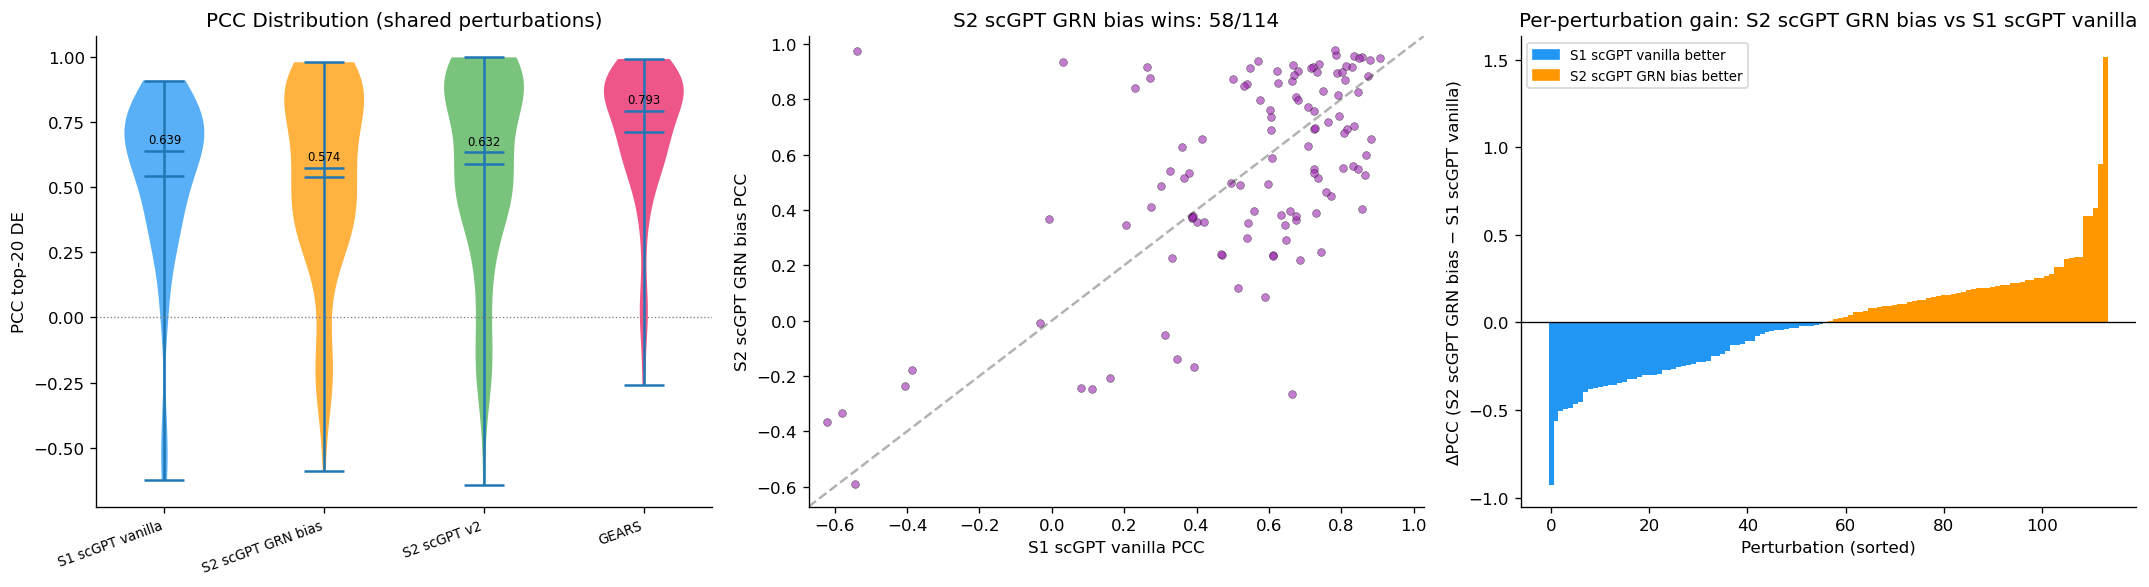

In [14]:
#5.1 PCC violin + pairwise scatter + delta bar (first two models)
if len(labels_ok) < 2:
    print('Need >= 2 models for comparison plots.')
else:
    shared = sorted(set.intersection(*[set(model_dfs[l]['perturbation']) for l in labels_ok]))
    pcc_vals = {l: model_dfs[l].set_index('perturbation').loc[shared, 'pcc_top20'].values
                for l in labels_ok}

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Violin
    parts = axes[0].violinplot([pcc_vals[l] for l in labels_ok], showmeans=True, showmedians=True)
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors_map[labels_ok[i]]); pc.set_alpha(0.75)
    axes[0].set_xticks(range(1, len(labels_ok)+1))
    axes[0].set_xticklabels(labels_ok, rotation=20, ha='right', fontsize=8)
    axes[0].set_ylabel('PCC top-20 DE')
    axes[0].set_title('PCC Distribution (shared perturbations)')
    axes[0].axhline(0, ls=':', c='gray', lw=0.8)
    # Add median text
    for i, l in enumerate(labels_ok):
        med = np.median(pcc_vals[l])
        axes[0].text(i+1, med+0.03, f'{med:.3f}', ha='center', fontsize=7)
    sns.despine(ax=axes[0])

    # Pairwise scatter: first vs second model
    l0, l1 = labels_ok[0], labels_ok[1]
    v0, v1 = pcc_vals[l0], pcc_vals[l1]
    axes[1].scatter(v0, v1, alpha=0.6, s=22, color='#9C27B0', edgecolors='k', lw=0.3)
    lim = [min(v0.min(), v1.min())-0.05, max(v0.max(), v1.max())+0.05]
    axes[1].plot(lim, lim, 'k--', alpha=0.3)
    axes[1].set_xlim(lim); axes[1].set_ylim(lim)
    axes[1].set_xlabel(f'{l0} PCC'); axes[1].set_ylabel(f'{l1} PCC')
    n_wins = (v1 > v0).sum()
    axes[1].set_title(f'{l1} wins: {n_wins}/{len(shared)}')
    sns.despine(ax=axes[1])

    # Delta bar (sorted)
    delta = v1 - v0
    order = np.argsort(delta)
    bar_cols = [colors_map[l1] if d > 0 else colors_map[l0] for d in delta[order]]
    axes[2].bar(range(len(delta)), delta[order], color=bar_cols, width=1.0)
    axes[2].axhline(0, color='black', lw=0.8)
    axes[2].set_xlabel('Perturbation (sorted)')
    axes[2].set_ylabel(f'ΔPCC ({l1} − {l0})')
    axes[2].set_title(f'Per-perturbation gain: {l1} vs {l0}')
    p0 = mpatches.Patch(color=colors_map[l0], label=f'{l0} better')
    p1 = mpatches.Patch(color=colors_map[l1], label=f'{l1} better')
    axes[2].legend(handles=[p0, p1], fontsize=8)
    sns.despine(ax=axes[2])

    plt.tight_layout()
    plt.savefig(OUT_DIR / 'pcc_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

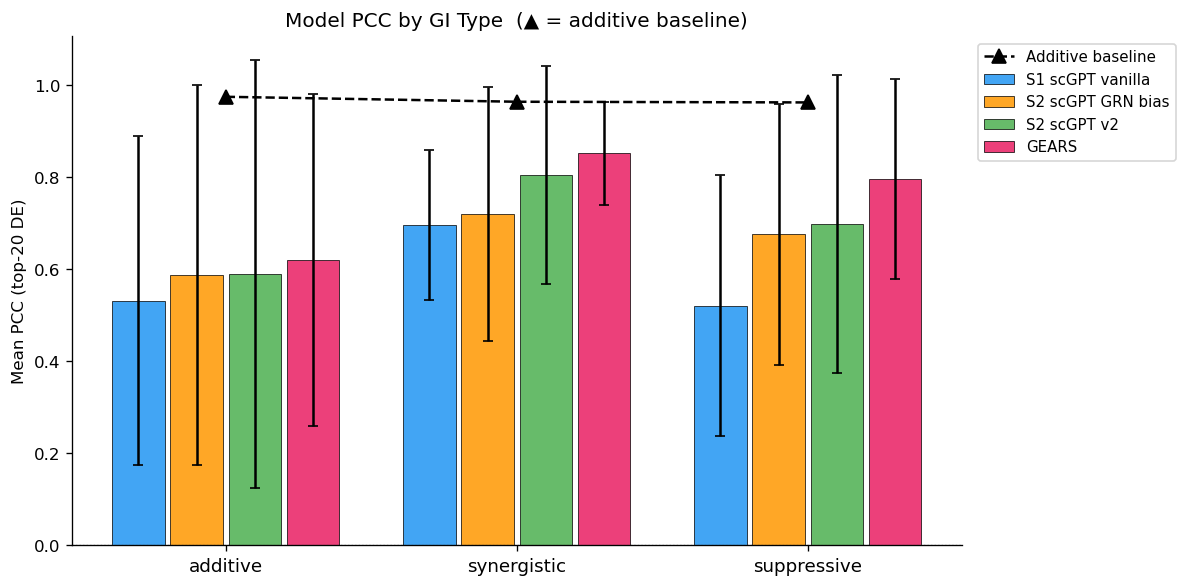

In [15]:
#5.2 Grouped bar: model PCC by GI type (with additive baseline overlay)
gi_present = [t for t in GI_ORDER if any(
    t in model_dfs[l]['gi_type'].values for l in labels_ok)]

x = np.arange(len(gi_present))
w = 0.8 / len(labels_ok)
fig, ax = plt.subplots(figsize=(10, 5))

for i, label in enumerate(labels_ok):
    df = model_dfs[label]
    means = [df[df['gi_type'] == gt]['pcc_top20'].mean() for gt in gi_present]
    stds  = [df[df['gi_type'] == gt]['pcc_top20'].std()  for gt in gi_present]
    offset = (i - len(labels_ok)/2 + 0.5) * w
    ax.bar(x + offset, means, w*0.9, yerr=stds, capsize=3,
           label=label, color=colors_map[label], alpha=0.85, edgecolor='k', lw=0.5)

# Additive baseline (ground truth, same for all models)
add_means = [gi_df[gi_df['gi_type'] == gt]['pcc_additive_top20'].mean()
             if gt in gi_df['gi_type'].values else np.nan for gt in gi_present]
ax.plot(x, add_means, 'k^--', markersize=8, lw=1.5, label='Additive baseline', zorder=5)

ax.set_xticks(x); ax.set_xticklabels(gi_present, fontsize=11)
ax.set_ylabel('Mean PCC (top-20 DE)')
ax.set_title('Model PCC by GI Type  (▲ = additive baseline)')
ax.legend(fontsize=9, bbox_to_anchor=(1.01, 1), loc='upper left')
ax.axhline(0, color='gray', ls=':', lw=0.8)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(OUT_DIR / 'gi_type_bar.png', dpi=150, bbox_inches='tight')
plt.show()

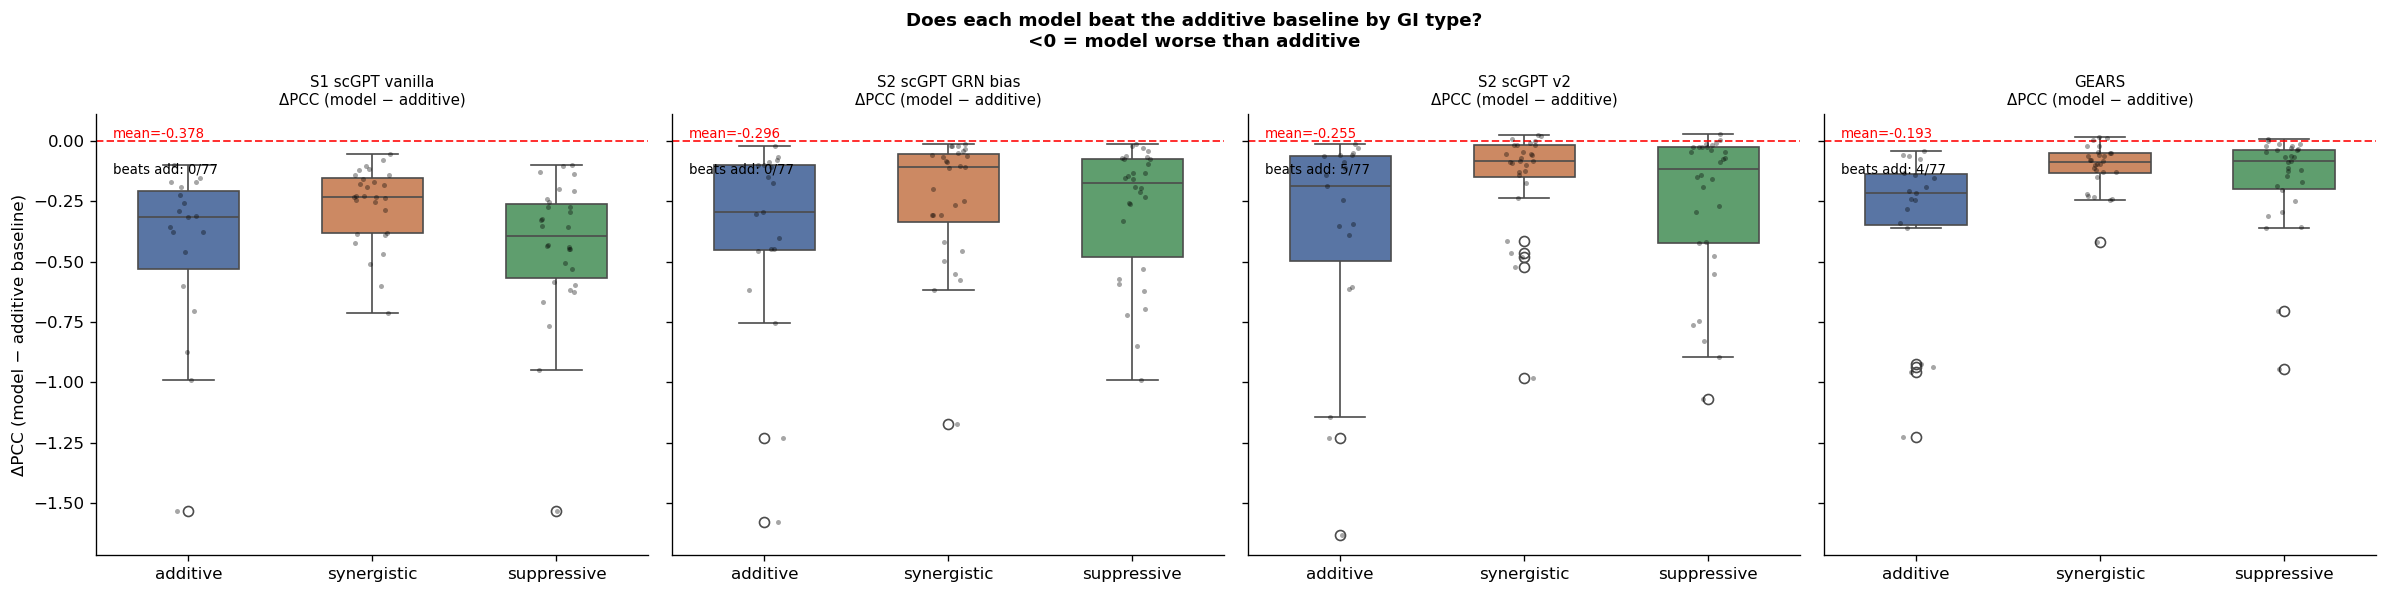

In [16]:
#5.3 ΔPCC (model - additive) by GI type — one panel per model
n_m = len(labels_ok)
fig, axes = plt.subplots(1, n_m, figsize=(5*n_m, 5), sharey=True)
if n_m == 1: axes = [axes]

for ax, label in zip(axes, labels_ok):
    df = model_dfs[label].copy()
    sub = df[df['gi_type'].isin(gi_present)].copy()
    sub['delta_pcc'] = sub['pcc_top20'] - sub['pcc_additive_top20']

    sns.boxplot(data=sub, x='gi_type', y='delta_pcc', order=gi_present,
                palette=palette, ax=ax, width=0.55)
    sns.stripplot(data=sub, x='gi_type', y='delta_pcc', order=gi_present,
                  color='black', alpha=0.35, size=3, jitter=True, ax=ax)
    ax.axhline(0, color='red', ls='--', lw=1.2, alpha=0.8)
    ax.set_title(f'{label}\nΔPCC (model − additive)', fontsize=9)
    ax.set_xlabel('')
    mean_d = sub['delta_pcc'].mean()
    wins   = (sub['delta_pcc'] > 0).sum()
    ax.text(0.03, 0.97, f'mean={mean_d:+.3f}', transform=ax.transAxes,
            fontsize=8, va='top', color='red')
    ax.text(0.03, 0.89, f'beats add: {wins}/{len(sub)}', transform=ax.transAxes,
            fontsize=8, va='top')
    sns.despine(ax=ax)

axes[0].set_ylabel('ΔPCC (model − additive baseline)')
plt.suptitle('Does each model beat the additive baseline by GI type?\n<0 = model worse than additive',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'delta_pcc_by_gi.png', dpi=150, bbox_inches='tight')
plt.show()

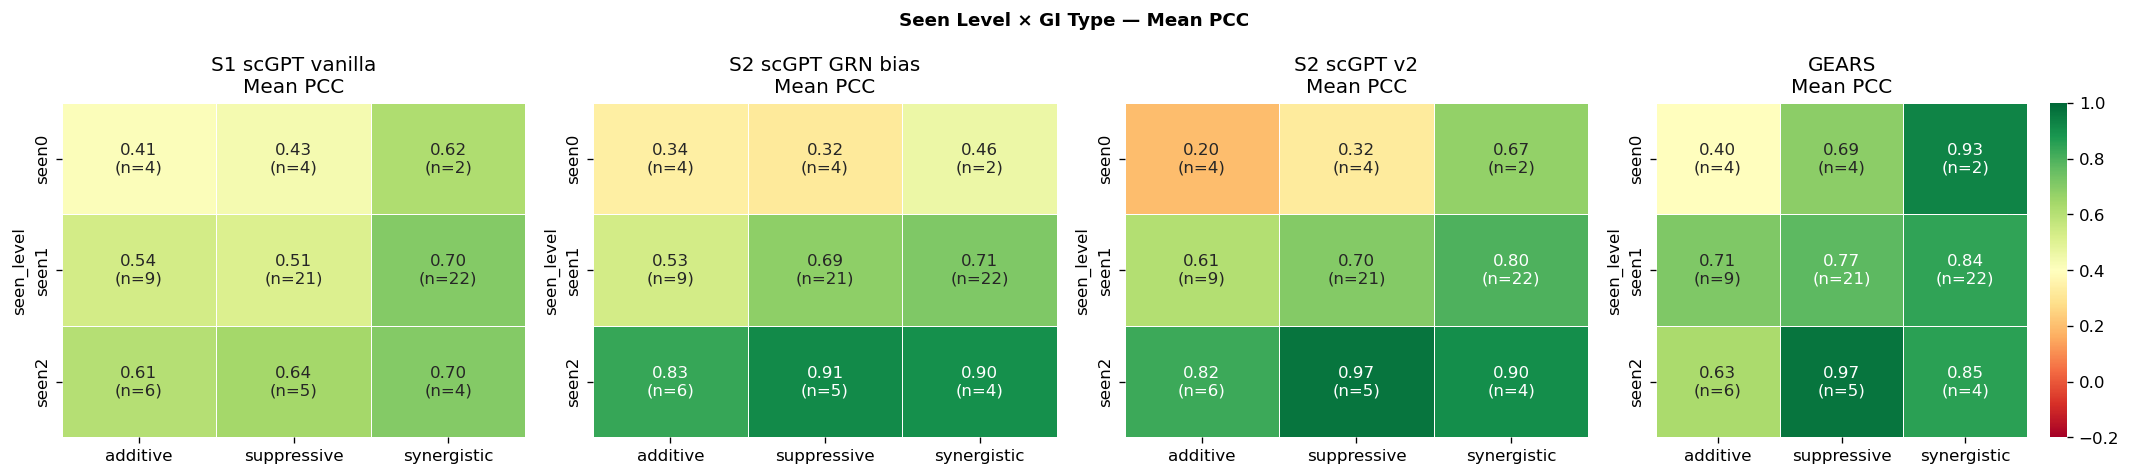

In [17]:
#5.4 Cross-tab heatmap: Seen Level × GI Type  — one per model
n_m = len(labels_ok)
fig, axes = plt.subplots(1, n_m, figsize=(4.5*n_m, 4))
if n_m == 1: axes = [axes]

for ax, label in zip(axes, labels_ok):
    df = model_dfs[label]
    sub = df[df['gi_type'].isin(GI_ORDER)]
    pcc_tab = sub.pivot_table(values='pcc_top20', index='seen_level',
                               columns='gi_type', aggfunc='mean')
    n_tab   = sub.pivot_table(values='perturbation', index='seen_level',
                               columns='gi_type', aggfunc='count')
    # Annotate with mean + count
    annot = pcc_tab.copy().astype(object)
    for col in pcc_tab.columns:
        for idx in pcc_tab.index:
            try:
                v = pcc_tab.loc[idx, col]
                n = int(n_tab.loc[idx, col]) if idx in n_tab.index and col in n_tab.columns else 0
                annot.loc[idx, col] = f'{v:.2f}\n(n={n})' if not np.isnan(v) else 'N/A'
            except Exception:
                annot.loc[idx, col] = 'N/A'
    sns.heatmap(pcc_tab, annot=annot, fmt='', cmap='RdYlGn', ax=ax,
                vmin=-0.2, vmax=1.0, linewidths=0.5, cbar=(ax == axes[-1]))
    ax.set_title(f'{label}\nMean PCC')
    ax.set_xlabel('')

plt.suptitle('Seen Level × GI Type — Mean PCC', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'heatmap_seen_x_gi.png', dpi=150, bbox_inches='tight')
plt.show()

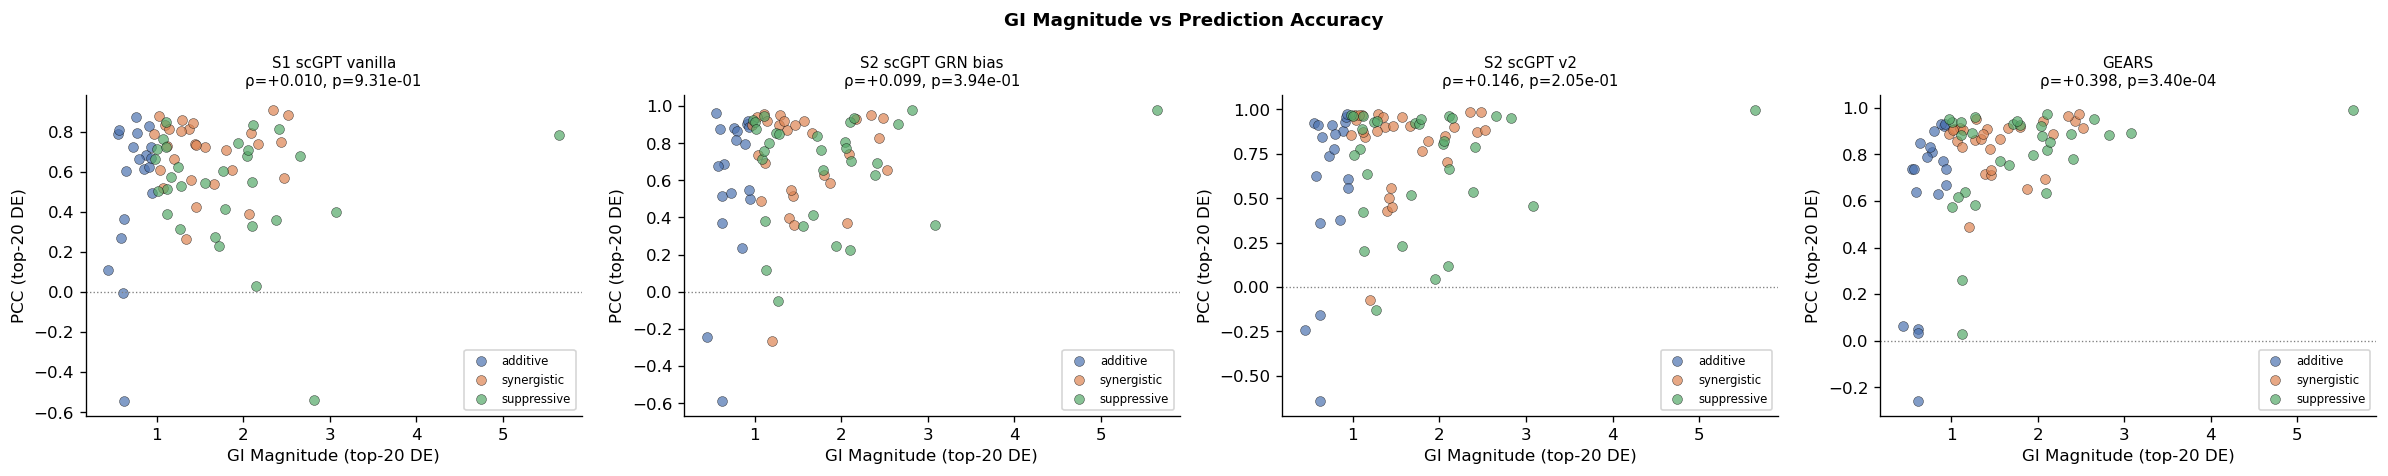

In [18]:
#5.5 GI magnitude vs prediction error scatter — one panel per model
n_m = len(labels_ok)
fig, axes = plt.subplots(1, n_m, figsize=(5*n_m, 4), sharey=False)
if n_m == 1: axes = [axes]

for ax, label in zip(axes, labels_ok):
    df = model_dfs[label].dropna(subset=['gi_magnitude_top20'])
    rho, pval = spearmanr(df['gi_magnitude_top20'], df['pcc_top20'])
    for gt in gi_present:
        sub = df[df['gi_type'] == gt]
        ax.scatter(sub['gi_magnitude_top20'], sub['pcc_top20'],
                   c=palette[gt], label=gt, alpha=0.7, edgecolors='k', lw=0.3, s=35)
    ax.axhline(0, color='gray', ls=':', lw=0.8)
    ax.set_xlabel('GI Magnitude (top-20 DE)')
    ax.set_ylabel('PCC (top-20 DE)')
    ax.set_title(f'{label}\nρ={rho:+.3f}, p={pval:.2e}', fontsize=9)
    ax.legend(fontsize=7)
    sns.despine(ax=ax)

plt.suptitle('GI Magnitude vs Prediction Accuracy', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'gi_magnitude_vs_pcc.png', dpi=150, bbox_inches='tight')
plt.show()

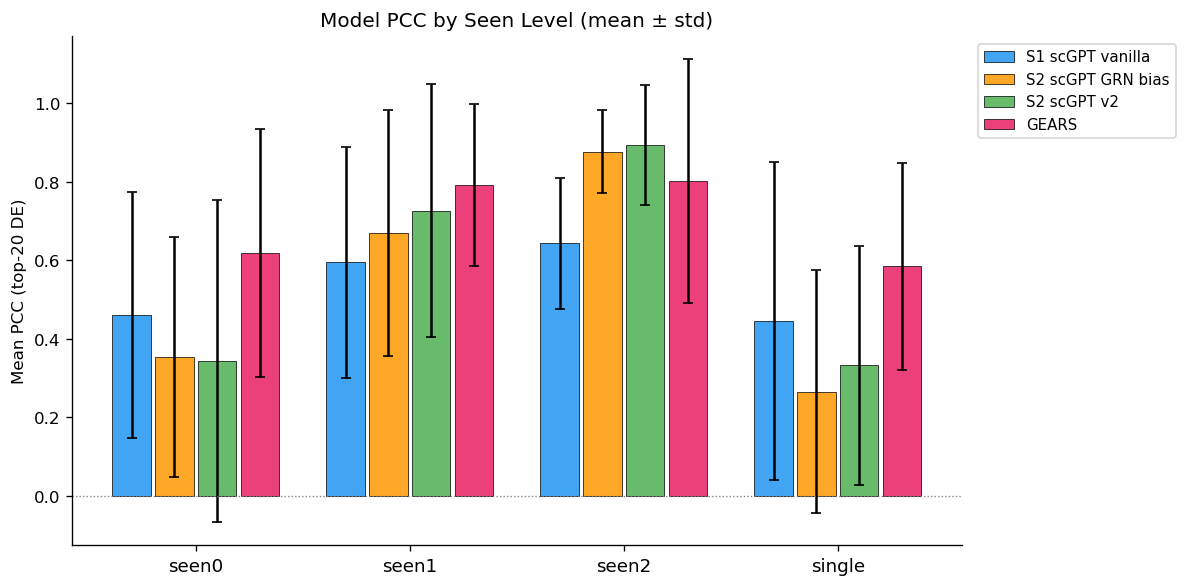

In [19]:
#5.6 Seen-level PCC bar chart — all models side by side
x = np.arange(len(SEEN_ORDER))
w = 0.8 / len(labels_ok)
fig, ax = plt.subplots(figsize=(10, 5))

for i, label in enumerate(labels_ok):
    df = model_dfs[label]
    means = [df[df['seen_level'] == lv]['pcc_top20'].mean() for lv in SEEN_ORDER]
    stds  = [df[df['seen_level'] == lv]['pcc_top20'].std()  for lv in SEEN_ORDER]
    offset = (i - len(labels_ok)/2 + 0.5) * w
    ax.bar(x + offset, means, w*0.9, yerr=stds, capsize=3,
           label=label, color=colors_map[label], alpha=0.85, edgecolor='k', lw=0.5)

ax.set_xticks(x); ax.set_xticklabels(SEEN_ORDER, fontsize=11)
ax.set_ylabel('Mean PCC (top-20 DE)')
ax.set_title('Model PCC by Seen Level (mean ± std)')
ax.legend(fontsize=9, bbox_to_anchor=(1.01, 1), loc='upper left')
ax.axhline(0, color='gray', ls=':', lw=0.8)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(OUT_DIR / 'seen_level_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Statistical Tests

In [20]:
#6.1 Mann-Whitney: does GI type affect ΔPCC (model − additive)?
print('Mann-Whitney U — ΔPCC by GI type (additive vs each other type)')
print('Interpretation: significant = model gap differs across GI types')
for label in labels_ok:
    df = model_dfs[label].copy()
    sub = df[df['gi_type'].isin(gi_present)].copy()
    sub['delta_pcc'] = sub['pcc_top20'] - sub['pcc_additive_top20']
    ref = sub.loc[sub['gi_type'] == 'additive', 'delta_pcc']
    print(f'\n  [{label}]')
    for gt in ['synergistic', 'suppressive', 'neomorphic']:
        other = sub.loc[sub['gi_type'] == gt, 'delta_pcc']
        if len(ref) < 3 or len(other) < 3:
            print(f'    additive vs {gt:<12}: insufficient data')
            continue
        stat, pval = mannwhitneyu(ref, other, alternative='two-sided')
        sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
        print(f'    additive vs {gt:<12}: U={stat:.0f}  p={pval:.4f}  {sig}')

Mann-Whitney U — ΔPCC by GI type (additive vs each other type)
Interpretation: significant = model gap differs across GI types

  [S1 scGPT vanilla]
    additive vs synergistic : U=182  p=0.0703  ns
    additive vs suppressive : U=307  p=0.6591  ns
    additive vs neomorphic  : insufficient data

  [S2 scGPT GRN bias]
    additive vs synergistic : U=201  p=0.1620  ns
    additive vs suppressive : U=244  p=0.4059  ns
    additive vs neomorphic  : insufficient data

  [S2 scGPT v2]
    additive vs synergistic : U=169  p=0.0364  *
    additive vs suppressive : U=224  p=0.2144  ns
    additive vs neomorphic  : insufficient data

  [GEARS]
    additive vs synergistic : U=123  p=0.0020  **
    additive vs suppressive : U=157  p=0.0089  **
    additive vs neomorphic  : insufficient data


In [21]:
#6.2 Spearman: GI magnitude vs model PCC and MSE
print('Spearman correlation — GI magnitude vs model performance')
print(f'{"Model":<28} {"ρ(PCC)":>8} {"p(PCC)":>10} {"ρ(MSE)":>8} {"p(MSE)":>10}')
print('-' * 68)
for label in labels_ok:
    df = model_dfs[label].dropna(subset=['gi_magnitude_top20', 'pcc_top20', 'mse_top20'])
    r_pcc, p_pcc = spearmanr(df['gi_magnitude_top20'], df['pcc_top20'])
    r_mse, p_mse = spearmanr(df['gi_magnitude_top20'], df['mse_top20'])
    print(f'{label:<28} {r_pcc:>+8.3f} {p_pcc:>10.3e} {r_mse:>+8.3f} {p_mse:>10.3e}')

Spearman correlation — GI magnitude vs model performance
Model                          ρ(PCC)     p(PCC)   ρ(MSE)     p(MSE)
--------------------------------------------------------------------
S1 scGPT vanilla               +0.010  9.306e-01   +0.510  2.205e-06
S2 scGPT GRN bias              +0.099  3.939e-01   +0.453  3.460e-05
S2 scGPT v2                    +0.146  2.052e-01   +0.356  1.473e-03
GEARS                          +0.398  3.396e-04   +0.146  2.041e-01


In [22]:
#6.3 Top improved / regressed cases (first two models)
if len(labels_ok) >= 2:
    l0, l1 = labels_ok[0], labels_ok[1]
    shared = sorted(set.intersection(*[set(model_dfs[l]['perturbation']) for l in labels_ok]))
    df_cmp = pd.DataFrame({
        'perturbation': shared,
        l0: model_dfs[l0].set_index('perturbation').loc[shared, 'pcc_top20'].values,
        l1: model_dfs[l1].set_index('perturbation').loc[shared, 'pcc_top20'].values,
    })
    df_cmp['gi_type'] = [model_dfs[l0].set_index('perturbation').loc[p, 'gi_type'] for p in shared]
    df_cmp['delta'] = df_cmp[l1] - df_cmp[l0]

    print(f'Top 10 where {l1} improved most vs {l0}:')
    print(df_cmp.nlargest(10, 'delta')[['perturbation', 'gi_type', l0, l1, 'delta']].round(4).to_string(index=False))
    print(f'\nTop 10 where {l1} regressed most vs {l0}:')
    print(df_cmp.nsmallest(10, 'delta')[['perturbation', 'gi_type', l0, l1, 'delta']].round(4).to_string(index=False))

Top 10 where S2 scGPT GRN bias improved most vs S1 scGPT vanilla:
perturbation     gi_type  S1 scGPT vanilla  S2 scGPT GRN bias  delta
 CEBPB+MAPK1 suppressive           -0.5375             0.9759 1.5133
  ETS2+MAPK1 suppressive            0.0306             0.9351 0.9045
ZBTB10+SNAI1 synergistic            0.2643             0.9181 0.6538
  ETS2+CEBPE suppressive            0.2290             0.8391 0.6100
 TGFBR2+ETS2    additive            0.2711             0.8766 0.6055
 TMSB4X+BAK1    additive           -0.0070             0.3678 0.3749
UBASH3B+OSR2 suppressive            0.5016             0.8749 0.3733
UBASH3B+CNN1 synergistic            0.5688             0.9368 0.3680
  DUSP9+PRTG suppressive            0.5479             0.9123 0.3645
MAP2K3+IKZF3 suppressive            0.5311             0.8489 0.3178

Top 10 where S2 scGPT GRN bias regressed most vs S1 scGPT vanilla:
 perturbation     gi_type  S1 scGPT vanilla  S2 scGPT GRN bias   delta
  FOSB+PTPN12 synergistic           

## 7. Export

In [23]:
#7.1 Save annotated CSVs per model + combined
for label in labels_ok:
    safe = label.replace(' ', '_').replace('/', '_')
    out = OUT_DIR / f'eval_{safe}.csv'
    model_dfs[label].to_csv(out, index=False)
    print(f'Saved: {out}')

# Combined table with all models on shared perturbations
if len(labels_ok) >= 2:
    shared = sorted(set.intersection(*[set(model_dfs[l]['perturbation']) for l in labels_ok]))
    anchor = model_dfs[labels_ok[0]][['perturbation', 'seen_level', 'gi_type',
                                      'gi_magnitude_top20', 'pcc_additive_top20']].copy()
    anchor = anchor[anchor['perturbation'].isin(shared)]
    for label in labels_ok:
        safe = label.replace(' ', '_')
        tmp = model_dfs[label][['perturbation', 'pcc_top20', 'mse_top20']].rename(
            columns={'pcc_top20': f'pcc_{safe}', 'mse_top20': f'mse_{safe}'})
        anchor = anchor.merge(tmp, on='perturbation', how='inner')
    anchor.to_csv(OUT_DIR / 'eval_combined.csv', index=False)
    print(f'\nCombined ({len(anchor)} shared perts): {OUT_DIR}/eval_combined.csv')

gi_df.to_csv(OUT_DIR / 'gi_annotations.csv', index=False)
print(f'\nAll outputs in: {OUT_DIR.resolve()}')
for f in sorted(OUT_DIR.iterdir()):
    print(f'  {f.name}')

Saved: output/eval_S1_scGPT_vanilla.csv
Saved: output/eval_S2_scGPT_GRN_bias.csv
Saved: output/eval_S2_scGPT_v2.csv
Saved: output/eval_GEARS.csv

Combined (114 shared perts): output/eval_combined.csv

All outputs in: /scratch/users/astar/imcb/hudh/PerturbT/notebooks/Evaluation/output
  delta_pcc_by_gi.png
  eval_GEARS.csv
  eval_S1_scGPT_vanilla.csv
  eval_S2_scGPT_GRN_bias.csv
  eval_S2_scGPT_v2.csv
  eval_combined.csv
  gi_annotations.csv
  gi_magnitude_vs_pcc.png
  gi_type_bar.png
  heatmap_seen_x_gi.png
  pcc_distribution.png
  seen_level_bar.png
